In [23]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
cd drive

[Errno 2] No such file or directory: 'drive'
/content/drive/MyDrive/emotion-music


In [ ]:
cd My Drive

/content/drive/My Drive


In [ ]:
cd emotion-music

/content/drive/MyDrive/emotion-music


In [25]:
pwd

'/content/drive/MyDrive/emotion-music'

In [ ]:
import pandas as pd

# Example of reading a CSV file
dataset_path = '/content/drive/MyDrive/emotion-music/dataset/emotion/data.csv'
print(dataset_path)
df = pd.read_csv(dataset_path)

print(df.head())


/content/drive/MyDrive/emotion-music/dataset/emotion/data.csv
   Unnamed: 0                                               path     label
0           0  Surprise/1bd930d6a1c717c11be33db74823f661cb53f...  Surprise
1           1       Surprise/cropped_emotions.100096~12fffff.png  Surprise
2           2  Surprise/0df0e470e33093f5b72a8197fa209d684032c...  Surprise
3           3       Surprise/cropped_emotions.260779~12fffff.png  Surprise
4           4       Surprise/cropped_emotions.263616~12fffff.png  Surprise


In [ ]:
import os
import cv2
from albumentations import Compose, HorizontalFlip, RandomBrightnessContrast, Resize

# Define a simple augmentation pipeline
augmentations = Compose([
    Resize(256, 256),  # Resize the image to 256x256
    HorizontalFlip(p=0.5),  # 50% chance of flipping the image horizontally
    RandomBrightnessContrast(p=0.2),  # Adjust brightness and contrast randomly
])

# Paths
input_folder ="dataset/emotion/dataset/Surprise"  # Folder containing the original images
output_folder = "dataset/emotion/dataset/Surprise"  # Folder to save the augmented images
os.makedirs(output_folder, exist_ok=True)  # Create output folder if it doesn't exist

# Process and augment each image
for filename in os.listdir(input_folder):
    if filename.endswith((".jpg", ".png", ".jpeg")):  # Check for image files
        # Load the image
        image_path = os.path.join(input_folder, filename)
        image = cv2.imread(image_path)
        if image is None:
            print(f"Could not read {image_path}, skipping...")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

        # Apply augmentations
        augmented = augmentations(image=image)["image"]

        # Save the augmented image
        output_path = os.path.join(output_folder, f"augmented_{filename}")
        cv2.imwrite(output_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))  # Save as BGR
        print(f"Saved augmented image: {output_path}")

print("Augmentation complete!")


Augmentation complete!


In [ ]:
import os
import cv2



# Paths
input_folder ="dataset/emotion/dataset/Angry"  # Folder containing the original images
output_folder = "dataset/emotion/dataset/Angry"  # Folder to save the augmented images
os.makedirs(output_folder, exist_ok=True)  # Create output folder if it doesn't exist

# Process and augment each image
for filename in os.listdir(input_folder):
    if filename.endswith((".jpg", ".png", ".jpeg")):  # Check for image files
        # Load the image
        image_path = os.path.join(input_folder, filename)
        image = cv2.imread(image_path)
        if image is None:
            print(f"Could not read {image_path}, skipping...")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

        # Apply augmentations
        augmented = augmentations(image=image)["image"]

        # Save the augmented image
        output_path = os.path.join(output_folder, f"augmented_{filename}")
        cv2.imwrite(output_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))  # Save as BGR
        print(f"Saved augmented image: {output_path}")

print("Augmentation complete!")


Augmentation complete!


In [ ]:
import os
import cv2
from albumentations import Compose, HorizontalFlip, RandomBrightnessContrast, Resize

# Define a simple augmentation pipeline
augmentations = Compose([
    Resize(256, 256),  # Resize the image to 256x256
    HorizontalFlip(p=0.5),  # 50% chance of flipping the image horizontally
    RandomBrightnessContrast(p=0.2),  # Adjust brightness and contrast randomly
])

# Paths
input_folder ="dataset/emotion/dataset/Ahegao"  # Folder containing the original images
output_folder = "dataset/emotion/dataset/Ahegao"  # Folder to save the augmented images
os.makedirs(output_folder, exist_ok=True)  # Create output folder if it doesn't exist

# Process and augment each image
for filename in os.listdir(input_folder):
    if filename.endswith((".jpg", ".png", ".jpeg")):  # Check for image files
        # Load the image
        image_path = os.path.join(input_folder, filename)
        image = cv2.imread(image_path)
        if image is None:
            print(f"Could not read {image_path}, skipping...")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

        # Apply augmentations
        augmented = augmentations(image=image)["image"]

        # Save the augmented image[
        output_path = os.path.join(output_folder, f"augmented_{filename}")
        cv2.imwrite(output_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))  # Save as BGR
        print(f"Saved augmented image: {output_path}")

print("Augmentation complete!")


Augmentation complete!


In [ ]:
df.shape

(15453, 3)

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Correct dataset path
dataset_path = "/content/drive/MyDrive/dataset/emotion/dataset"  # Ensure correct spelling

# Verify if the path exists
if os.path.exists(dataset_path):
    print("Dataset directory found!")
    print(os.listdir(dataset_path))  # List files in the dataset folder
else:
    print("Dataset directory not found. Please check the path.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset directory not found. Please check the path.


In [ ]:
pwd

'/content/drive/MyDrive/emotion-music'

Training set shape: (9600, 128, 128, 3) (9600,)
Testing set shape: (2400, 128, 128, 3) (2400,)


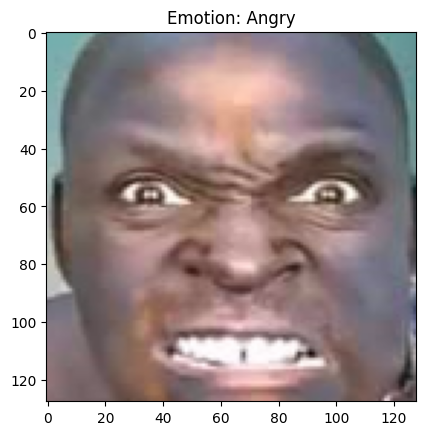

In [ ]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Define the paths to the dataset and emotion folders
dataset_path = '/content/drive/MyDrive/emotion-music/dataset/emotion/dataset'  # Update with your path
emotion_folders = ['Angry', 'Ahegao', 'Sad', 'Happy', 'Neutral', 'Surprise']  # Folder names representing emotions

# Initialize lists to store images and labels
images = []
labels = []

# Set the number of samples per class
num_samples = 2000  # Adjust as needed

# Load images from each emotion folder and add to the lists
for label, emotion in enumerate(emotion_folders):
    folder_path = os.path.join(dataset_path, emotion)

    # Check if the folder exists before proceeding
    if not os.path.exists(folder_path):
        print(f"Warning: Folder '{folder_path}' not found. Skipping...")
        continue  # Skip to the next emotion folder

    image_paths = [os.path.join(folder_path, img) for img in os.listdir(folder_path) if img.endswith(('.jpg', '.png'))]

    # Ensure we only take up to num_samples images per class
    sampled_paths = random.sample(image_paths, min(len(image_paths), num_samples))

    # Process the images in the sampled paths
    for img_path in sampled_paths:
        img = cv2.imread(img_path)  # Load in grayscale (or use cv2.IMREAD_COLOR for RGB)

        # Check if the image was loaded successfully
        if img is None:
            print(f"Error loading image: {img_path}. Skipping...")
            continue  # Skip to the next image

        img = cv2.resize(img, (128, 128))  # Resize to a fixed size
        images.append(img)
        labels.append(label)

# Convert lists to NumPy arrays
images = np.array(images, dtype=np.float32) / 255.0  # Normalize to [0, 1]
labels = np.array(labels, dtype=np.int32)

# Shuffle the dataset
indices = np.arange(len(images))
np.random.shuffle(indices)
images = images[indices]
labels = labels[indices]

# Split the dataset into training and testing sets (80-20 split)
xtrain, xtest, ytrain, ytest = train_test_split(images, labels, test_size=0.2)

# Print dataset shapes
print("Training set shape:", xtrain.shape, ytrain.shape)
print("Testing set shape:", xtest.shape, ytest.shape)

# Display a sample image from the training dataset
plt.imshow(xtrain[0])  # Display first image in the training set
plt.title(f"Emotion: {emotion_folders[ytrain[0]]}")
plt.show()


In [ ]:
np.save('xtrain.npy',xtrain)
np.save('xtest.npy',xtest)
np.save('ytrain',ytrain)
np.save('ytest',ytest)

In [ ]:
import numpy as np

# Load the saved datasets
xtrain = np.load('xtrain.npy')
xtest = np.load('xtest.npy')
ytrain = np.load('ytrain.npy')
ytest = np.load('ytest.npy')

# Check shapes to ensure data is loaded correctly
print("xtrain shape:", xtrain.shape)
print("xtest shape:", xtest.shape)
print("ytrain shape:", ytrain.shape)
print("ytest shape:", ytest.shape)


xtrain shape: (9600, 128, 128, 3)
xtest shape: (2400, 128, 128, 3)
ytrain shape: (9600,)
ytest shape: (2400,)


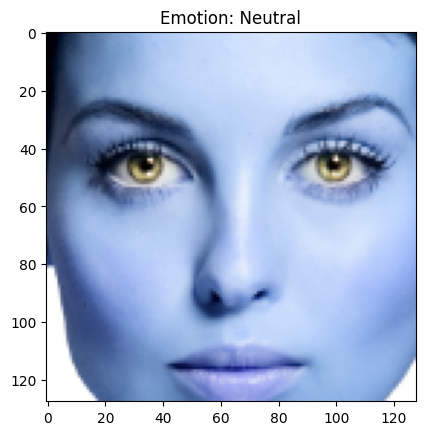

In [ ]:
import matplotlib.pyplot as plt
emotion_folders = ['Angry', 'Ahegao', 'Sad', 'Happy', 'Neutral', 'Surprise']  # Folder names representing emotions
# Display a sample image from the training dataset
plt.imshow(xtrain[1000])  # Display first image in the training set
plt.title(f"Emotion: {emotion_folders[ytrain[1000]]}")
plt.show()

In [ ]:
import os

# Set the path to your dataset folder
dataset_path = "/content/drive/MyDrive/emotion-music/dataset/emotion/dataset"

# List of emotion categories
emotions = ["Angry", "Happy", "Sad", "Surprise", "Neutral", "Ahegao"]

# Count images in each emotion folder
for emotion in emotions:
    emotion_path = os.path.join(dataset_path, emotion)
    if os.path.exists(emotion_path):
        num_images = len([f for f in os.listdir(emotion_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"{emotion}: {num_images} images")
    else:
        print(f"⚠️ Warning: Folder '{emotion}' does not exist!")


Angry: 2618 images
Happy: 3839 images
Sad: 3933 images
Surprise: 2492 images
Neutral: 4025 images
Ahegao: 3618 images


In [ ]:
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder to your labels and transform them to numerical values
y_train_encoded = label_encoder.fit_transform(ytrain)
y_test_encoded = label_encoder.fit_transform(ytest)

# Now use to_categorical on the encoded labels
y_train_categorical = to_categorical(y_train_encoded, num_classes=6)
y_test_categorical = to_categorical(y_test_encoded, num_classes=6)


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

import json

# ArcFace Loss
class ArcLoss(tf.keras.losses.Loss):
    """Additive angular margin loss."""
    def __init__(self, margin=0.5, scale=64, name="arcloss"):
        super().__init__(name=name)
        self.margin = margin
        self.scale = scale
        self.threshold = tf.math.cos(np.pi - margin)
        self.cos_m = tf.math.cos(margin)
        self.sin_m = tf.math.sin(margin)
        self.safe_margin = self.sin_m * margin

    @tf.function
    def call(self, y_true, y_pred):
        cos_t = y_pred
        sin_t = tf.math.sqrt(1 - tf.math.square(cos_t))

        cos_t_margin = tf.where(cos_t > self.threshold,
                                cos_t * self.cos_m - sin_t * self.sin_m,
                                cos_t - self.safe_margin)

        mask = y_true
        cos_t_onehot = cos_t * mask
        cos_t_margin_onehot = cos_t_margin * mask

        logits1 = (cos_t + cos_t_margin_onehot - cos_t_onehot) * self.scale
        losses = tf.nn.softmax_cross_entropy_with_logits(labels=y_true, logits=logits1)

        return losses

    def get_config(self):
        config = super(ArcLoss, self).get_config()
        config.update({"margin": self.margin, "scale": self.scale})
        return config

# Build the model with Dropout
model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Dropout layer to prevent overfitting
    layers.Dense(6, activation='linear'),  # Output logits for ArcFace
    layers.Lambda(lambda y: tf.nn.l2_normalize(y, axis=1))  # L2 normalization
])

# Compile model with ArcLoss
loss_fn = ArcLoss()
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

history = model.fit(xtrain,y_train_categorical,epochs=50, batch_size=4, validation_data=(xtest, y_test_categorical))


# Save the history dictionary as a JSON file
history_dict = history.history  # Get the history of the model
with open('training_history.json', 'w') as f:
    json.dump(history_dict, f)
# Save the trained model
model.save('faceemotion1234.h5')  # Saving the model in HDF5 format



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.2397 - loss: 38.8999 - val_accuracy: 0.5079 - val_loss: 30.1070
Epoch 2/50
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4744 - loss: 30.3810 - val_accuracy: 0.5554 - val_loss: 26.4561
Epoch 3/50
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.6019 - loss: 24.5874 - val_accuracy: 0.6137 - val_loss: 23.8131
Epoch 4/50
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.6726 - loss: 20.6971 - val_accuracy: 0.6108 - val_loss: 23.6232
Epoch 5/50
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7231 - loss: 17.6008 - val_accuracy: 0.6475 - val_loss: 21.5257
Epoch 6/50
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7649 - loss: 15.0172 - val_accuracy: 0.6425 - val_loss: 22.0531
Epoch 7/50
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8107 - loss: 12.4178 - val_accuracy: 0.6612 - val_loss: 20.6901
Epoch 8/50
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.

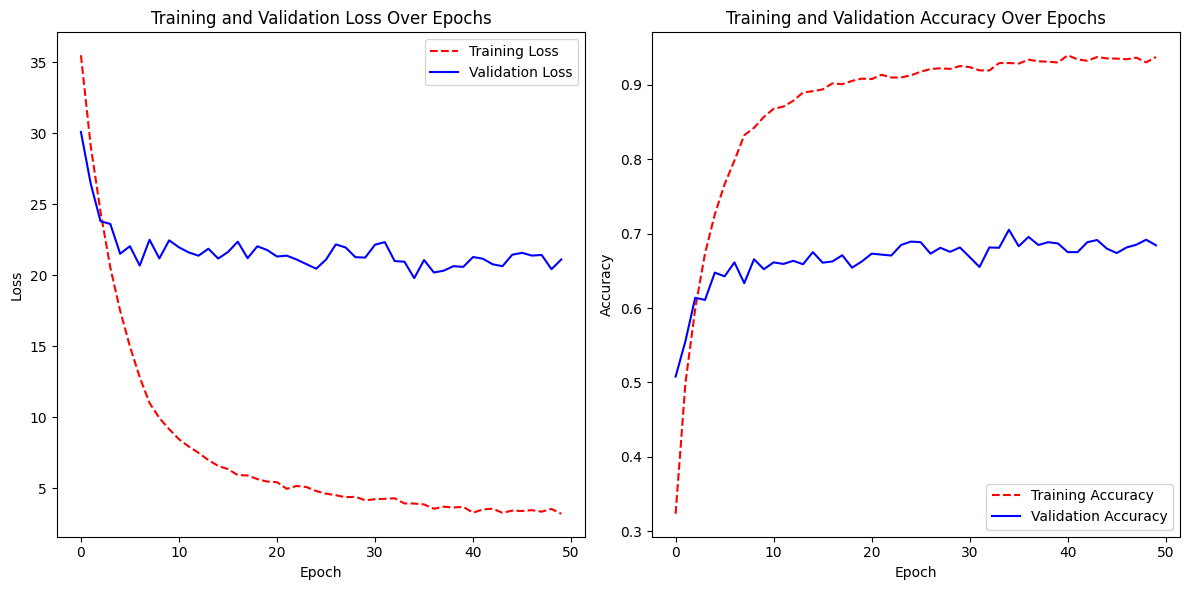

In [ ]:
import matplotlib.pyplot as plt
with open('training_history.json', 'r') as f:
    loaded_history = json.load(f)

# Now you can use loaded_history for analysis or plotting

def plot_loss_accuracy(history):
    # Extract the loss and accuracy values from the history object
    training_loss = history.history['loss']
    val_loss = history.history['val_loss']
    training_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    # Plot loss over epochs
    plt.figure(figsize=(12, 6))

    # Subplot for loss
    plt.subplot(1, 2, 1)
    plt.plot(training_loss, 'r--', label='Training Loss')
    plt.plot(val_loss, 'b-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss Over Epochs')

    # Subplot for accuracy
    plt.subplot(1, 2, 2)
    plt.plot(training_accuracy, 'r--', label='Training Accuracy')
    plt.plot(val_accuracy, 'b-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy Over Epochs')

    # Show the plots
    plt.tight_layout()
    plt.show()

# Call the function after training
if 'history' in locals():
    plot_loss_accuracy(history)
else:
    print("No training history found. Train the model first.")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


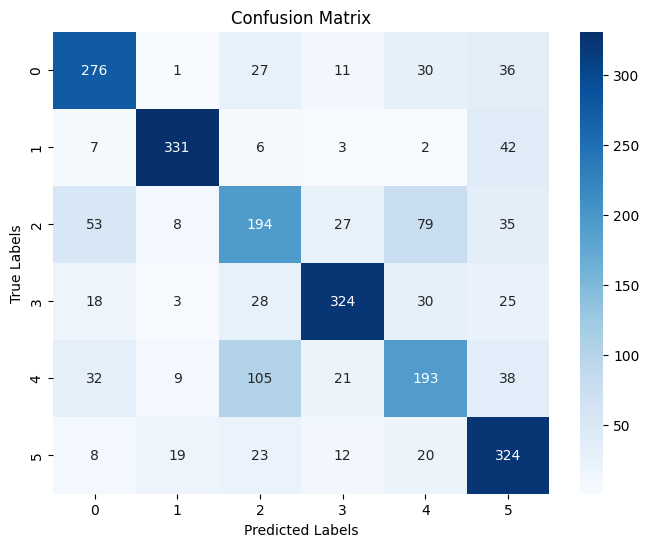

Precision: 0.69
Recall: 0.68


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score

class ArcLoss(tf.keras.losses.Loss):
    """Additive angular margin loss."""
    def __init__(self, margin=0.5, scale=64, name="arcloss"):
        super().__init__(name=name)
        self.margin = margin
        self.scale = scale
        self.threshold = tf.math.cos(np.pi - margin)
        self.cos_m = tf.math.cos(margin)
        self.sin_m = tf.math.sin(margin)
        self.safe_margin = self.sin_m * margin

    @tf.function
    def call(self, y_true, y_pred):
        cos_t = y_pred
        sin_t = tf.math.sqrt(1 - tf.math.square(cos_t))

        cos_t_margin = tf.where(cos_t > self.threshold,
                                cos_t * self.cos_m - sin_t * self.sin_m,
                                cos_t - self.safe_margin)

        mask = y_true
        cos_t_onehot = cos_t * mask
        cos_t_margin_onehot = cos_t_margin * mask

        logits1 = (cos_t + cos_t_margin_onehot - cos_t_onehot) * self.scale
        losses = tf.nn.softmax_cross_entropy_with_logits(labels=y_true, logits=logits1)

        return losses

    def get_config(self):
        config = super(ArcLoss, self).get_config()
        config.update({"margin": self.margin, "scale": self.scale})
        return config

# Build the model with Dropout
base_model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Dropout layer to prevent overfitting
    layers.Dense(6, activation='linear'),  # Output logits for ArcFace
    layers.Lambda(lambda y: tf.nn.l2_normalize(y, axis=1))  # L2 normalization
])

# Load pre-trained weights
base_model.load_weights('faceemotion1234.h5')

# Compile model with ArcLoss
loss_fn = ArcLoss()
optimizer = Adam(learning_rate=1e-4)
base_model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# Assuming xtest and y_test_categorical are defined and available

# Step 2: Predict the class labels for the test set
y_pred = base_model.predict(xtest)  # Get the model predictions

# Step 3: Convert predictions to class labels
y_pred_labels = np.argmax(y_pred, axis=1)  # Convert predictions to class labels

# Step 4: Convert the true labels to class labels (from one-hot encoding)
y_true_labels = np.argmax(y_test_categorical, axis=1)

# Step 5: Generate the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Step 6: Calculate Precision and Recall
precision = precision_score(y_true_labels, y_pred_labels, average='weighted')  # 'weighted' averages for multi-class
recall = recall_score(y_true_labels, y_pred_labels, average='weighted')

# Step 7: Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(6), yticklabels=np.arange(6))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Step 8: Print Precision and Recall
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score

class ArcLoss(tf.keras.losses.Loss):
    """Additive angular margin loss."""
    def __init__(self, margin=0.5, scale=64, name="arcloss"):
        super().__init__(name=name)
        self.margin = margin
        self.scale = scale
        self.threshold = tf.math.cos(np.pi - margin)
        self.cos_m = tf.math.cos(margin)
        self.sin_m = tf.math.sin(margin)
        self.safe_margin = self.sin_m * margin

    @tf.function
    def call(self, y_true, y_pred):
        cos_t = y_pred
        sin_t = tf.math.sqrt(1 - tf.math.square(cos_t))

        cos_t_margin = tf.where(cos_t > self.threshold,
                                cos_t * self.cos_m - sin_t * self.sin_m,
                                cos_t - self.safe_margin)

        mask = y_true
        cos_t_onehot = cos_t * mask
        cos_t_margin_onehot = cos_t_margin * mask

        logits1 = (cos_t + cos_t_margin_onehot - cos_t_onehot) * self.scale
        losses = tf.nn.softmax_cross_entropy_with_logits(labels=y_true, logits=logits1)

        return losses

    def get_config(self):
        config = super(ArcLoss, self).get_config()
        config.update({"margin": self.margin, "scale": self.scale})
        return config

# Build the model with Dropout
base_model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Dropout layer to prevent overfitting
    layers.Dense(6, activation='linear'),  # Output logits for ArcFace
    layers.Lambda(lambda y: tf.nn.l2_normalize(y, axis=1))  # L2 normalization
])

# Load pre-trained weights
base_model.load_weights('faceemotion1234.h5')

# Compile model with ArcLoss
loss_fn = ArcLoss()
optimizer = Adam(learning_rate=1e-4)
base_model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
base_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       6,422,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             774 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_2 (Lambda)                    │ (None, 6)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,447,014 (24.59 MB)

 Trainable params: 6,447,014 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


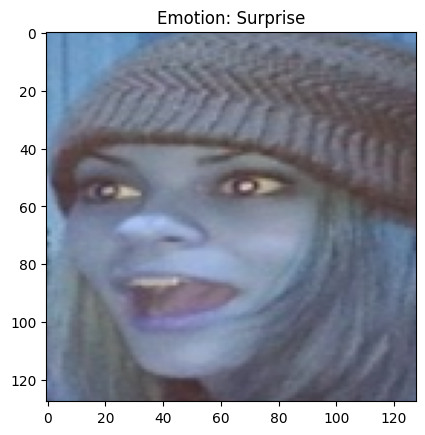

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
# Assuming base_model is defined and loaded as in your previous code snippets

emotion_folders = ['Angry', 'Ahegao', 'Sad', 'Happy', 'Neutral', 'Surprise']

# Get predictions for xtest
y_pred = base_model.predict(xtest)

# Get predicted labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Now you can use y_pred_labels
plt.imshow(xtest[50])
plt.title(f"Emotion: {emotion_folders[y_pred_labels[50]]}")
plt.show()

In [ ]:
pip install gradio opencv-python deepface numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.1 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=831cbb076a4

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
import cv2
import os
from tensorflow.keras import models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from google.colab import files
from IPython.display import Audio, display
import time

# Define emotion labels in order of model output
emotion_labels = ['Angry', 'Ahegao', 'Sad', 'Happy', 'Neutral', 'Surprise']

# Map emotions to song files (Ensure these MP3 files exist in the correct folder)
emotion_songs = {
    "Angry": "songs/Angry.mp3",
    "Ahegao": "songs/Ahegao.mp3",
    "Sad": "songs/Sad.mp3",
    "Happy": "songs/Happy.mp3",
    "Neutral": "songs/Neutral.mp3",
    "Surprise": "songs/Surprise.mp3"
}

class ArcLoss(tf.keras.losses.Loss):
    """Additive angular margin loss."""
    def __init__(self, margin=0.5, scale=64, name="arcloss"):
        super().__init__(name=name)
        self.margin = margin
        self.scale = scale
        self.threshold = tf.math.cos(np.pi - margin)
        self.cos_m = tf.math.cos(margin)
        self.sin_m = tf.math.sin(margin)
        self.safe_margin = self.sin_m * margin

    @tf.function
    def call(self, y_true, y_pred):
        cos_t = y_pred
        sin_t = tf.math.sqrt(1 - tf.math.square(cos_t))
        cos_t_margin = tf.where(cos_t > self.threshold,
                                cos_t * self.cos_m - sin_t * self.sin_m,
                                cos_t - self.safe_margin)
        mask = y_true
        cos_t_onehot = cos_t * mask
        cos_t_margin_onehot = cos_t_margin * mask
        logits1 = (cos_t + cos_t_margin_onehot - cos_t_onehot) * self.scale
        losses = tf.nn.softmax_cross_entropy_with_logits(labels=y_true, logits=logits1)
        return losses

    def get_config(self):
        config = super(ArcLoss, self).get_config()
        config.update({"margin": self.margin, "scale": self.scale})
        return config

# Build the model with Dropout
base_model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='linear'),
    layers.Lambda(lambda y: tf.nn.l2_normalize(y, axis=1))
])

# Load pre-trained weights
base_model.load_weights('faceemotion1234.h5')

# Compile model with ArcLoss
loss_fn = ArcLoss()
optimizer = Adam(learning_rate=1e-4)
base_model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def play_song(emotion):
    """Plays or provides a download link for the detected emotion song."""
    song_path = emotion_songs.get(emotion, None)

    if song_path and os.path.exists(song_path):
        print(f"🎵 Playing song for emotion: {emotion}")

        # Display audio player for direct playback in Colab
        display(Audio(song_path, autoplay=True))

        # Provide download link as an alternative
        print(f"⬇️ Click below to download the song for '{emotion}'")
        files.download(song_path)

        time.sleep(1)  # Prevents multiple downloads happening too fast
    else:
        print(f"❌ No song found for emotion: {emotion}")

def recognize_emotions(image):
    """Detects faces in an image, recognizes emotions, and plays a song."""
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        return image

    for (x, y, w, h) in faces:
        face_roi = image_bgr[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (128, 128))
        face_roi = np.array(face_roi, dtype=np.float32) / 255.0
        face_roi = np.expand_dims(face_roi, axis=0)

        # Predict emotion
        predictions = base_model.predict(face_roi)
        emotion_index = np.argmax(predictions)
        emotion = emotion_labels[emotion_index]

        # Play or download the song based on emotion
        play_song(emotion)

        # Draw a rectangle around the face and label it
        cv2.rectangle(image_bgr, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(image_bgr, emotion, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Create Gradio interface with webcam
iface = gr.Interface(
    fn=recognize_emotions,
    inputs=gr.Image(type="numpy"),
    outputs="image",
    title="Face Emotion Recognition with Music",
    description="Detects emotions and plays or provides a download link for a song based on the detected emotion.",
    live=True
)

# Launch the app
iface.launch(debug=True)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://195a38425cf12fbbd8.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://195a38425cf12fbbd8.gradio.live


In [39]:
import gradio as gr
import tensorflow as tf
import numpy as np
import cv2
import os
from tensorflow.keras import models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from google.colab import files
from IPython.display import Audio, display, Javascript
import time
import base64
from google.colab import output

# Define emotion labels in order of model output
emotion_labels = ['Angry', 'Ahegao', 'Sad', 'Happy', 'Neutral', 'Surprise']

# Map emotions to song files (Ensure these MP3 files exist in the correct folder)
emotion_songs = {
    "Angry": "/content/drive/MyDrive/emotion-music/dataset/songs/Angry.mp3",
    "Ahegao": "/content/drive/MyDrive/emotion-music/dataset/songs/Ahegao.mp3",
    "Sad": "/content/drive/MyDrive/emotion-music/dataset/songs/Sad.mp3",
    "Happy": "/content/drive/MyDrive/emotion-music/dataset/songs/Happy.mp3",
    "Neutral": "/content/drive/MyDrive/emotion-music/dataset/songs/Neutral.mp3",
    "Surprise": "/content/drive/MyDrive/emotion-music/dataset/songs/Surprise.mp3"
}

# Define ArcLoss
class ArcLoss(tf.keras.losses.Loss):
    def __init__(self, margin=0.5, scale=64, name="arcloss"):
        super().__init__(name=name)
        self.margin = margin
        self.scale = scale
        self.threshold = tf.math.cos(np.pi - margin)
        self.cos_m = tf.math.cos(margin)
        self.sin_m = tf.math.sin(margin)
        self.safe_margin = self.sin_m * margin

    @tf.function
    def call(self, y_true, y_pred):
        cos_t = y_pred
        sin_t = tf.math.sqrt(1 - tf.math.square(cos_t))
        cos_t_margin = tf.where(cos_t > self.threshold,
                                cos_t * self.cos_m - sin_t * self.sin_m,
                                cos_t - self.safe_margin)
        mask = y_true
        cos_t_onehot = cos_t * mask
        cos_t_margin_onehot = cos_t_margin * mask
        logits1 = (cos_t + cos_t_margin_onehot - cos_t_onehot) * self.scale
        losses = tf.nn.softmax_cross_entropy_with_logits(labels=y_true, logits=logits1)
        return losses

    def get_config(self):
        config = super().get_config()
        config.update({"margin": self.margin, "scale": self.scale})
        return config

# Build the model
base_model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='linear'),
    layers.Lambda(lambda y: tf.nn.l2_normalize(y, axis=1))
])

# Load pre-trained weights
base_model.load_weights('/content/drive/MyDrive/emotion-music/faceemotion1234.h5')

# Compile model
base_model.compile(optimizer=Adam(learning_rate=1e-4), loss=ArcLoss(), metrics=['accuracy'])

# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Function to play the song
def play_song(emotion):
    song_path = emotion_songs.get(emotion, None)
    if song_path and os.path.exists(song_path):
        display(Audio(song_path, autoplay=True))
        print(f"Playing song for {emotion}. Click below to download:")
        files.download(song_path)
        time.sleep(1)
    else:
        print(f"No song found for emotion: {emotion}")

# JavaScript to capture an image from the webcam
def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({ video: true });

            document.body.appendChild(video);
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => setTimeout(resolve, 2000));

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            const ctx = canvas.getContext('2d');
            ctx.drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();

            const imageDataUrl = canvas.toDataURL('image/jpeg');
            google.colab.kernel.invokeFunction('notebook.saveImage', [imageDataUrl], {});
        }
        takePhoto();
    ''')
    display(js)

# Function to save image
def save_image(imageDataUrl):
    try:
        print("Saving image...")
        image_data = base64.b64decode(imageDataUrl.split(',')[1])

        # Use a unique filename for each capture
        timestamp = int(time.time())
        image_path = f"photo_{timestamp}.jpg"

        with open(image_path, "wb") as f:
            f.write(image_data)

        if os.path.exists(image_path):
            print(f"Image saved successfully: {image_path}")
        else:
            print("Image saving failed!")

    except Exception as e:
        print(f"Error saving image: {e}")

output.register_callback('notebook.saveImage', save_image)

# Function to detect emotion
def detect_emotion_from_webcam():
    print("Capturing image from webcam...")
    take_photo()

    # Wait for the image to be saved before proceeding
    timeout = 30  # Increased timeout to 20 seconds
    start_time = time.time()
    image_path = None

    while True:
        # Find the latest image file
        image_files = [f for f in os.listdir() if f.startswith("photo_") and f.endswith(".jpg")]
        if image_files:
            image_path = max(image_files, key=os.path.getctime)  # Get the most recent image
            break
        if time.time() - start_time > timeout:
            print("Error: Image capture timed out.")
            return None
        time.sleep(1)  # Wait for the image to be saved

    image = cv2.imread(image_path)
    if image is None:
        print("Error: Image could not be loaded.")
        return None

    # Process the image
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        print("No face detected.")
        return image_rgb

    for (x, y, w, h) in faces:
        face_roi = image_rgb[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (128, 128))
        face_roi = np.array(face_roi, dtype=np.float32) / 255.0
        face_roi = np.expand_dims(face_roi, axis=0)

        predictions = base_model.predict(face_roi)
        emotion_index = np.argmax(predictions)
        emotion = emotion_labels[emotion_index]

        play_song(emotion)

        cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(image_rgb, emotion, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    return image_rgb

# Gradio interface (only for image display)
iface = gr.Interface(
    fn=detect_emotion_from_webcam,
    inputs=None,
    outputs="image",
    title="Face Emotion Recognition with Music",
    description="Detects emotions from a webcam image and plays a song based on the detected emotion."
)

# Launch Gradio
iface.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7fae56509c4898f828.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Capturing image from webcam...


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step


Playing song for Happy. Click below to download:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://7fae56509c4898f828.gradio.live


Saving image...
Image saved successfully: photo_1774577554.jpg
